# **Household Energy Consumption Prediction and High-Consumption Classification**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving energydata_complete.csv to energydata_complete.csv


In [ ]:
df = pd.read_csv("energydata_complete.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (19735, 29)


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [ ]:
df.dtypes

,0
date,object
Appliances,int64
lights,int64
T1,float64
RH_1,float64
T2,float64
RH_2,float64
T3,float64
RH_3,float64
T4,float64


In [ ]:
df.describe()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


**Data Preprocessing**

In [ ]:
df["date"] = pd.to_datetime(df["date"])
df["hour"] = df["date"].dt.hour
df["day"] = df["date"].dt.day
df["month"] = df["date"].dt.month
df["weekday"] = df["date"].dt.weekday
df = df.drop(columns=["date"])
df.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,hour,day,month,weekday
0,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,...,92.0,7.000000,63.000000,5.3,13.275433,13.275433,17,11,1,0
1,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,...,92.0,6.666667,59.166667,5.2,18.606195,18.606195,17,11,1,0
2,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,...,92.0,6.333333,55.333333,5.1,28.642668,28.642668,17,11,1,0
3,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,...,92.0,6.000000,51.500000,5.0,45.410389,45.410389,17,11,1,0
4,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,...,92.0,5.666667,47.666667,4.9,10.084097,10.084097,17,11,1,0


In [ ]:
missing_values = df.isnull().sum()
missing_summary = missing_values[missing_values > 0]
print("Columns with missing values:")
print(missing_summary if len(missing_summary) > 0 else "No missing values found.")

Columns with missing values:
No missing values found.


In [ ]:
if df.isnull().sum().sum() > 0:
    df = df.fillna(df.median(numeric_only=True))
    print("Missing values were imputed using the median of each column.")
else:
    print("No imputation required.")

No imputation required.


In [ ]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed. New shape:", df.shape)

Number of duplicate rows: 0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 32 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Appliances   19735 non-null  int64  
 1   lights       19735 non-null  int64  
 2   T1           19735 non-null  float64
 3   RH_1         19735 non-null  float64
 4   T2           19735 non-null  float64
 5   RH_2         19735 non-null  float64
 6   T3           19735 non-null  float64
 7   RH_3         19735 non-null  float64
 8   T4           19735 non-null  float64
 9   RH_4         19735 non-null  float64
 10  T5           19735 non-null  float64
 11  RH_5         19735 non-null  float64
 12  T6           19735 non-null  float64
 13  RH_6         19735 non-null  float64
 14  T7           19735 non-null  float64
 15  RH_7         19735 non-null  float64
 16  T8           19735 non-null  float64
 17  RH_8         19735 non-null  float64
 18  T9           19735 non-null  float64
 19  RH_9

**Exploratory Data Analysis**

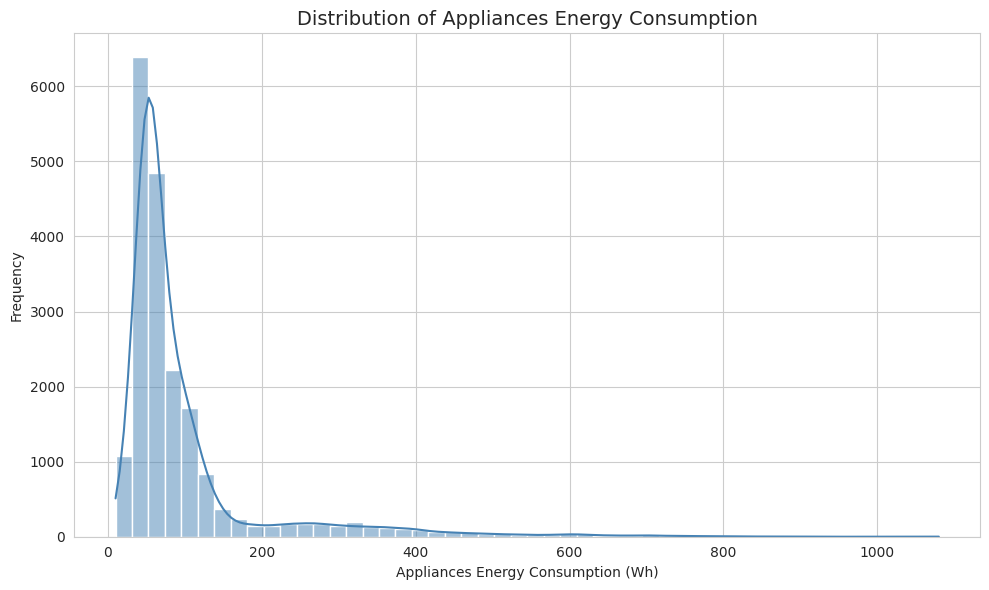

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df["Appliances"], bins=50, kde=True, color="steelblue")
plt.title("Distribution of Appliances Energy Consumption", fontsize=14)
plt.xlabel("Appliances Energy Consumption (Wh)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

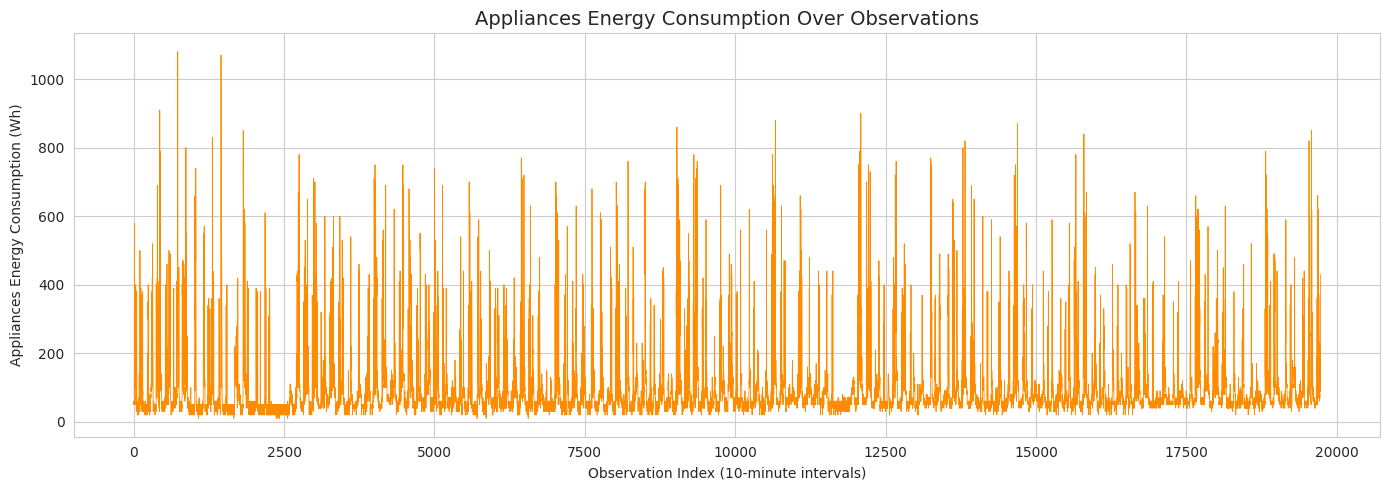

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(df["Appliances"].values, color="darkorange", linewidth=0.6)
plt.title("Appliances Energy Consumption Over Observations", fontsize=14)
plt.xlabel("Observation Index (10-minute intervals)")
plt.ylabel("Appliances Energy Consumption (Wh)")
plt.tight_layout()
plt.show()

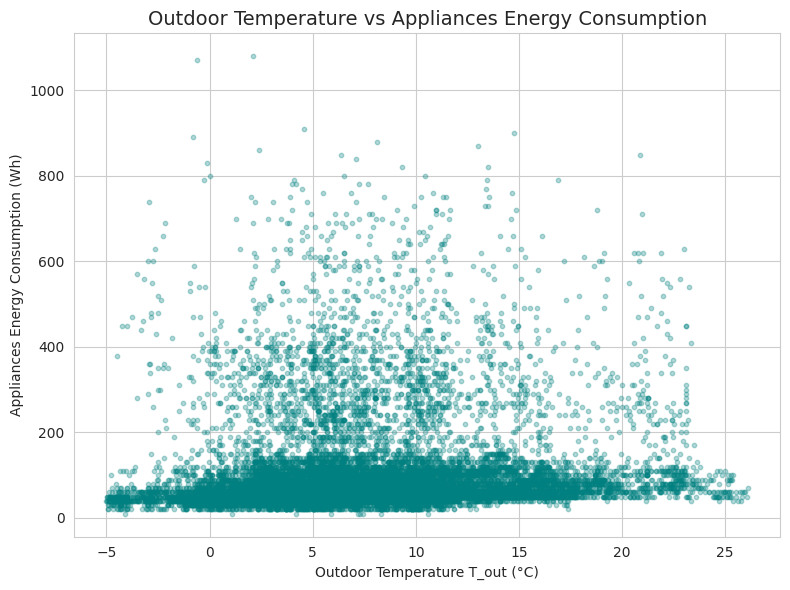

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df["T_out"], df["Appliances"], alpha=0.3, s=10, color="teal")
plt.title("Outdoor Temperature vs Appliances Energy Consumption", fontsize=14)
plt.xlabel("Outdoor Temperature T_out (°C)")
plt.ylabel("Appliances Energy Consumption (Wh)")
plt.tight_layout()
plt.show()

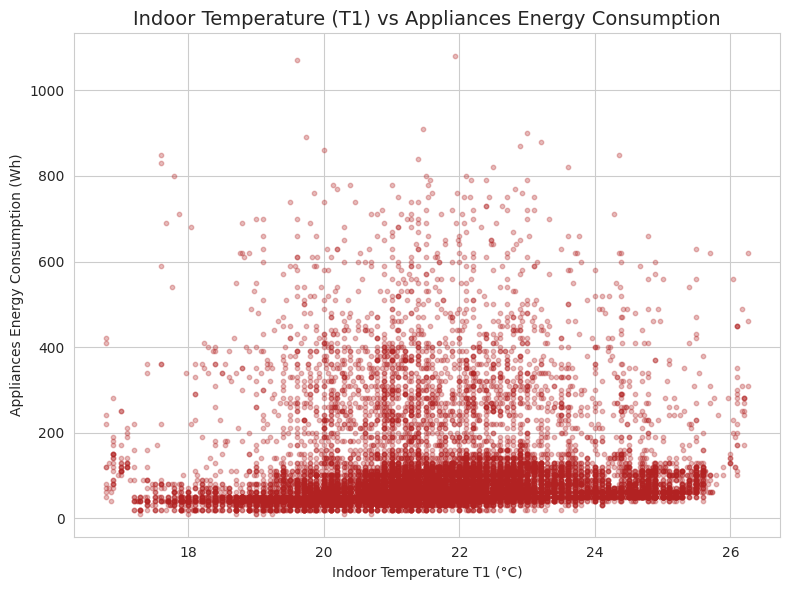

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df["T1"], df["Appliances"], alpha=0.3, s=10, color="firebrick")
plt.title("Indoor Temperature (T1) vs Appliances Energy Consumption", fontsize=14)
plt.xlabel("Indoor Temperature T1 (°C)")
plt.ylabel("Appliances Energy Consumption (Wh)")
plt.tight_layout()
plt.show()

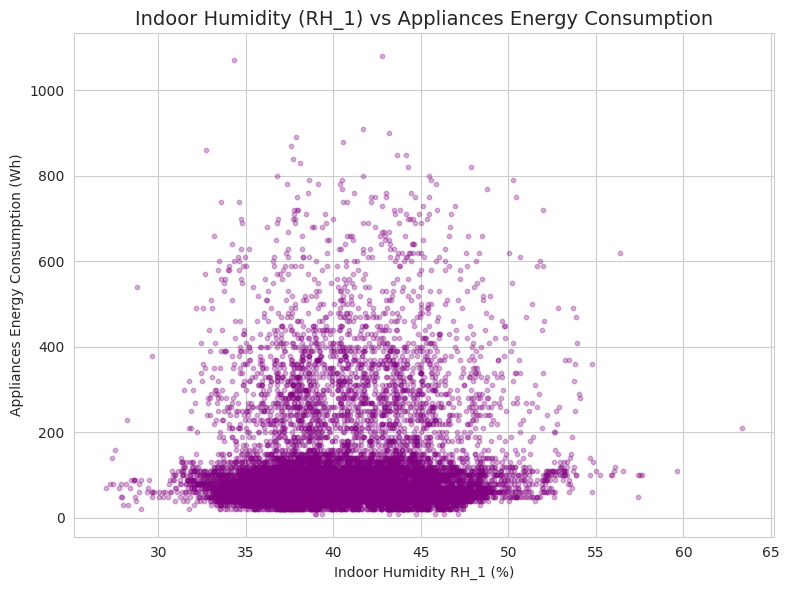

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df["RH_1"], df["Appliances"], alpha=0.3, s=10, color="purple")
plt.title("Indoor Humidity (RH_1) vs Appliances Energy Consumption", fontsize=14)
plt.xlabel("Indoor Humidity RH_1 (%)")
plt.ylabel("Appliances Energy Consumption (Wh)")
plt.tight_layout()
plt.show()

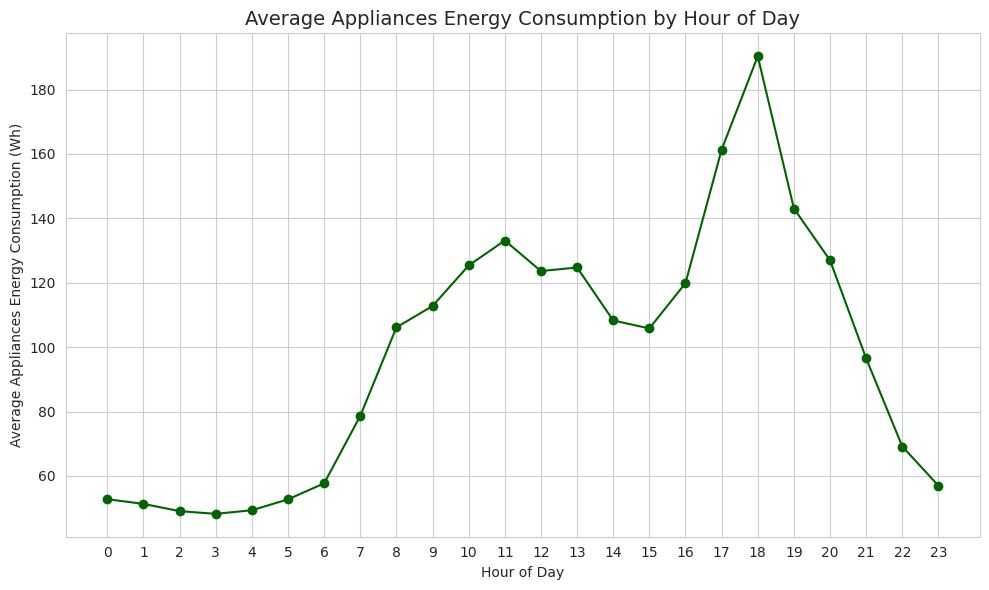

In [ ]:
hourly_avg = df.groupby("hour")["Appliances"].mean()

plt.figure(figsize=(10, 6))
plt.plot(hourly_avg.index, hourly_avg.values, marker="o", color="darkgreen")
plt.title("Average Appliances Energy Consumption by Hour of Day", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Average Appliances Energy Consumption (Wh)")
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()

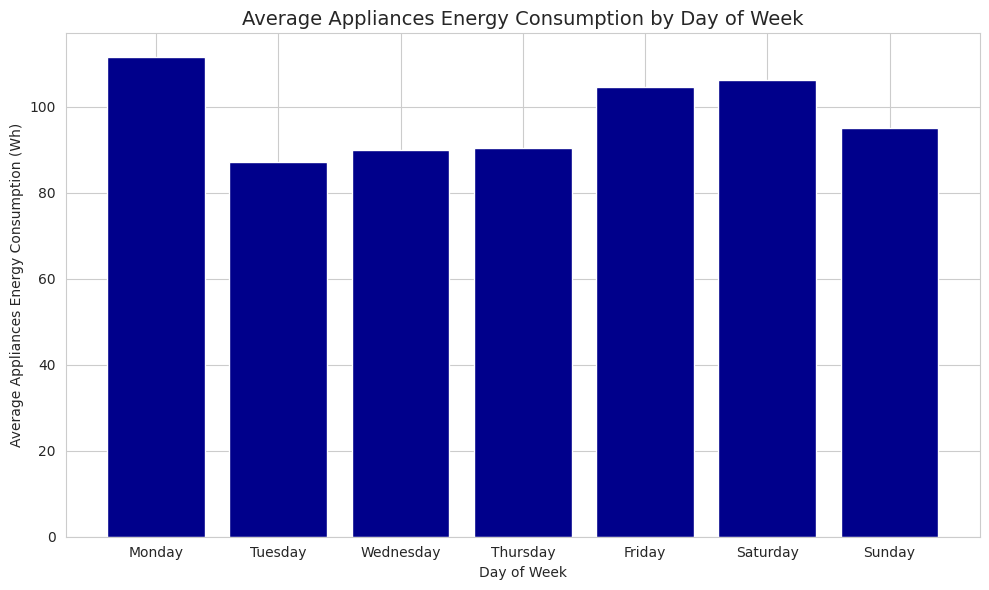

In [ ]:
weekday_labels = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_avg = df.groupby("weekday")["Appliances"].mean()

plt.figure(figsize=(10, 6))
plt.bar(weekday_labels, weekday_avg.values, color="darkblue")
plt.title("Average Appliances Energy Consumption by Day of Week", fontsize=14)
plt.xlabel("Day of Week")
plt.ylabel("Average Appliances Energy Consumption (Wh)")
plt.tight_layout()
plt.show()

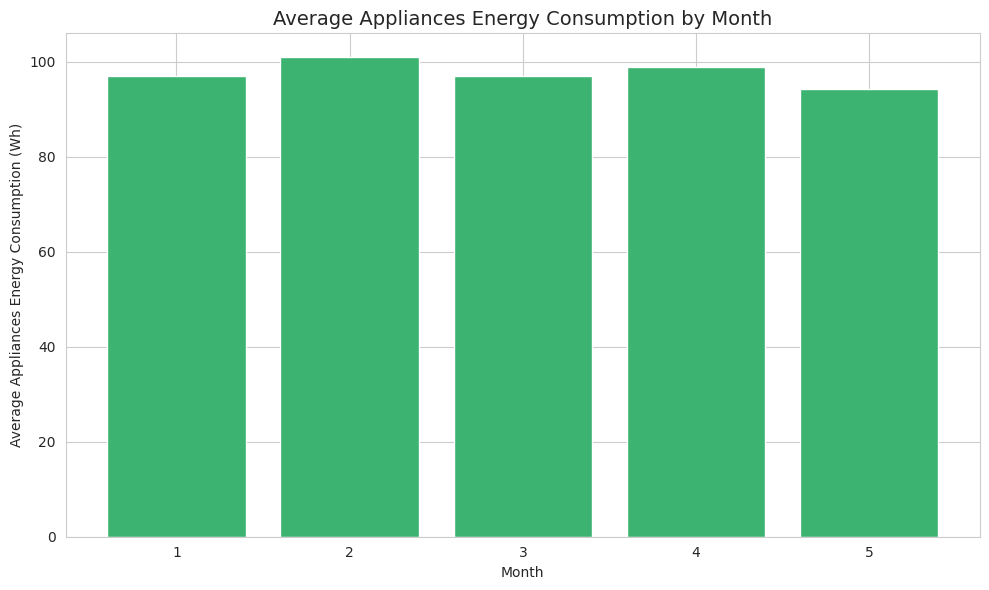

In [ ]:
monthly_avg = df.groupby("month")["Appliances"].mean()

plt.figure(figsize=(10, 6))
plt.bar(monthly_avg.index.astype(str), monthly_avg.values, color="mediumseagreen")
plt.title("Average Appliances Energy Consumption by Month", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Average Appliances Energy Consumption (Wh)")
plt.tight_layout()
plt.show()

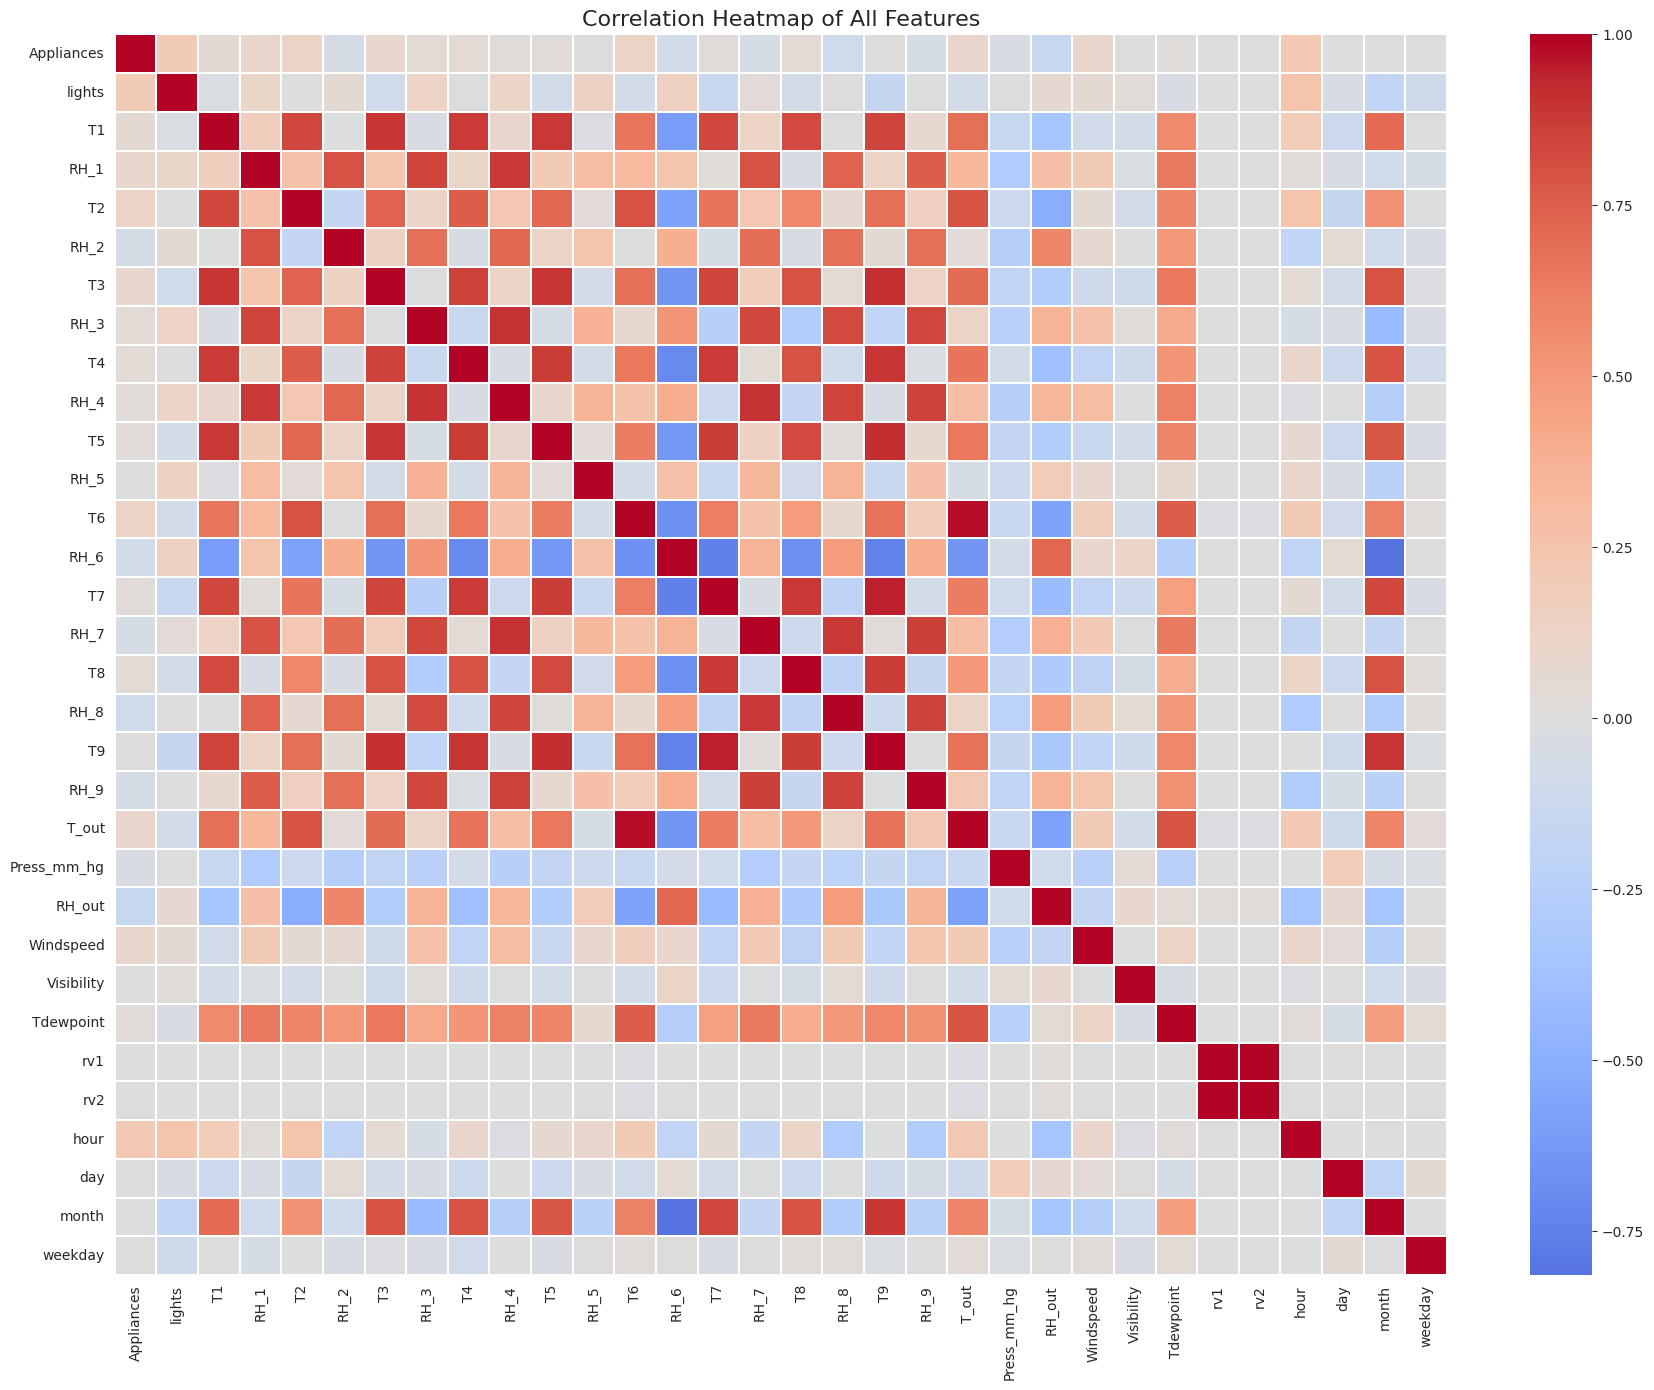

In [ ]:
plt.figure(figsize=(18, 14))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0, annot=False, linewidths=0.3)
plt.title("Correlation Heatmap of All Features", fontsize=16)
plt.tight_layout()
plt.show()

**Regression**

In [ ]:
X_reg = df.drop(columns=["Appliances"])
y_reg = df["Appliances"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

print("Training set shape:", X_train_reg.shape)
print("Test set shape:", X_test_reg.shape)

Training set shape: (15788, 31)
Test set shape: (3947, 31)


In [ ]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

regression_results = {}
regression_predictions = {}

**Linear Regression**

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg_scaled, y_train_reg)
y_pred_lin = lin_reg.predict(X_test_reg_scaled)

regression_results["Linear Regression"] = regression_metrics(y_test_reg, y_pred_lin)
regression_predictions["Linear Regression"] = y_pred_lin

pd.DataFrame(regression_results).T

,MAE,MSE,RMSE,R2
Linear Regression,52.569734,8303.540929,91.123767,0.170234


**Polynomial Regression**

In [ ]:
poly_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("linreg", LinearRegression())
])

poly_pipeline.fit(X_train_reg, y_train_reg)
y_pred_poly = poly_pipeline.predict(X_test_reg)

regression_results["Polynomial Regression"] = regression_metrics(y_test_reg, y_pred_poly)
regression_predictions["Polynomial Regression"] = y_pred_poly

pd.DataFrame({"Polynomial Regression": regression_results["Polynomial Regression"]}).T

,MAE,MSE,RMSE,R2
Polynomial Regression,48.753069,6796.38611,82.440197,0.320843


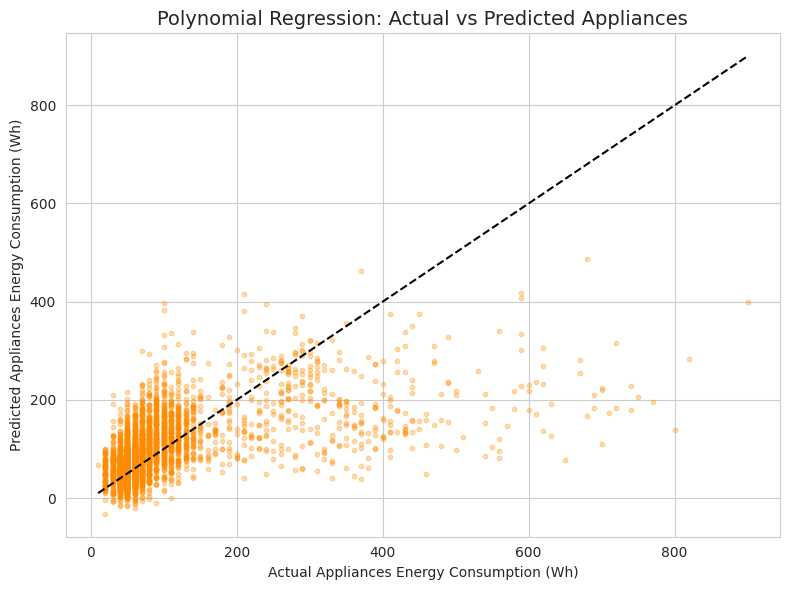

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_poly, alpha=0.3, s=10, color="darkorange")
plt.plot(
    [y_test_reg.min(), y_test_reg.max()],
    [y_test_reg.min(), y_test_reg.max()],
    color="black",
    linestyle="--"
)
plt.title("Polynomial Regression: Actual vs Predicted Appliances", fontsize=14)
plt.xlabel("Actual Appliances Energy Consumption (Wh)")
plt.ylabel("Predicted Appliances Energy Consumption (Wh)")
plt.tight_layout()
plt.show()

**Ridge Regression**

In [ ]:
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0, random_state=RANDOM_STATE))
])

ridge_pipeline.fit(X_train_reg, y_train_reg)
y_pred_ridge = ridge_pipeline.predict(X_test_reg)

regression_results["Ridge Regression"] = regression_metrics(y_test_reg, y_pred_ridge)
regression_predictions["Ridge Regression"] = y_pred_ridge

pd.DataFrame({"Ridge Regression": regression_results["Ridge Regression"]}).T

,MAE,MSE,RMSE,R2
Ridge Regression,52.565697,8303.323373,91.122573,0.170256


**Lasso Regression**

In [ ]:
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=0.1, max_iter=10000, random_state=RANDOM_STATE))
])

lasso_pipeline.fit(X_train_reg, y_train_reg)
y_pred_lasso = lasso_pipeline.predict(X_test_reg)

regression_results["Lasso Regression"] = regression_metrics(y_test_reg, y_pred_lasso)
regression_predictions["Lasso Regression"] = y_pred_lasso

pd.DataFrame({"Lasso Regression": regression_results["Lasso Regression"]}).T

,MAE,MSE,RMSE,R2
Lasso Regression,52.439292,8298.148076,91.094171,0.170773


**Regression Model Comparison**

In [ ]:
regression_comparison = pd.DataFrame(regression_results).T
regression_comparison = regression_comparison[["MAE", "MSE", "RMSE", "R2"]]
regression_comparison

,MAE,MSE,RMSE,R2
Linear Regression,52.569734,8303.540929,91.123767,0.170234
Polynomial Regression,48.753069,6796.386110,82.440197,0.320843
Ridge Regression,52.565697,8303.323373,91.122573,0.170256
Lasso Regression,52.439292,8298.148076,91.094171,0.170773


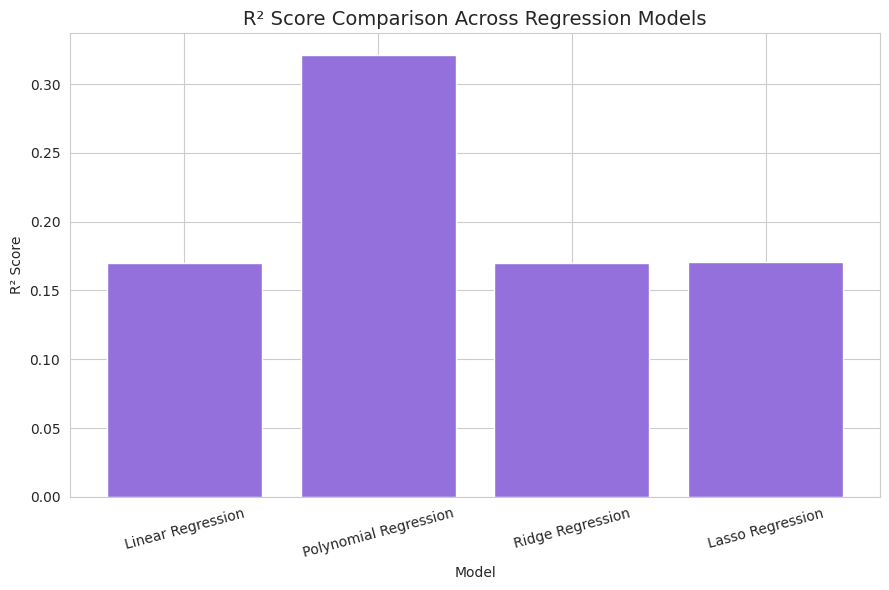

In [ ]:
plt.figure(figsize=(9, 6))
plt.bar(regression_comparison.index, regression_comparison["R2"], color="mediumpurple")
plt.title("R² Score Comparison Across Regression Models", fontsize=14)
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

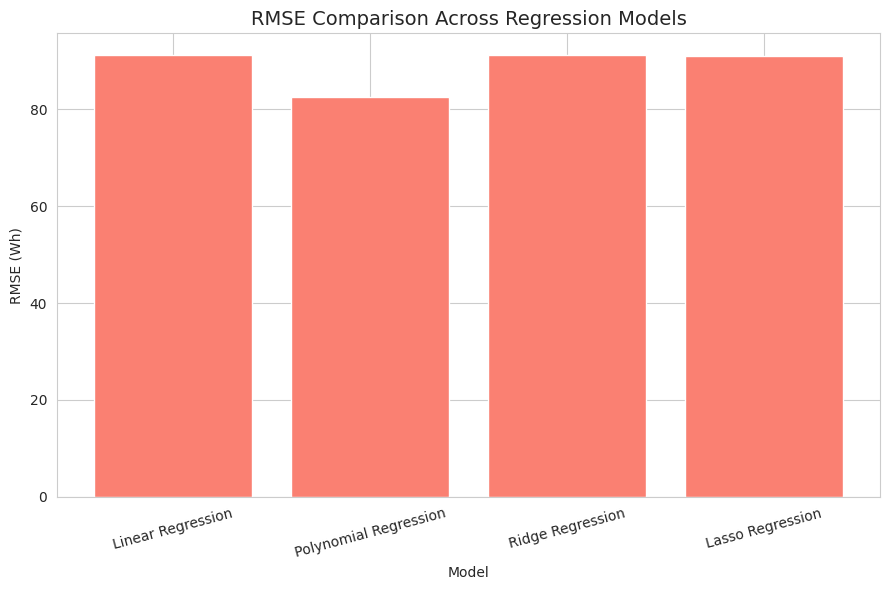

In [ ]:
plt.figure(figsize=(9, 6))
plt.bar(regression_comparison.index, regression_comparison["RMSE"], color="salmon")
plt.title("RMSE Comparison Across Regression Models", fontsize=14)
plt.xlabel("Model")
plt.ylabel("RMSE (Wh)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
best_regression_model = regression_comparison["R2"].idxmax()
print("Best regression model based on R2 score:", best_regression_model)
print(regression_comparison.loc[best_regression_model])

Best regression model based on R2 score: Polynomial Regression
MAE       48.753069
MSE     6796.386110
RMSE      82.440197
R2         0.320843
Name: Polynomial Regression, dtype: float64


**Actual vs Predicted Visualization**

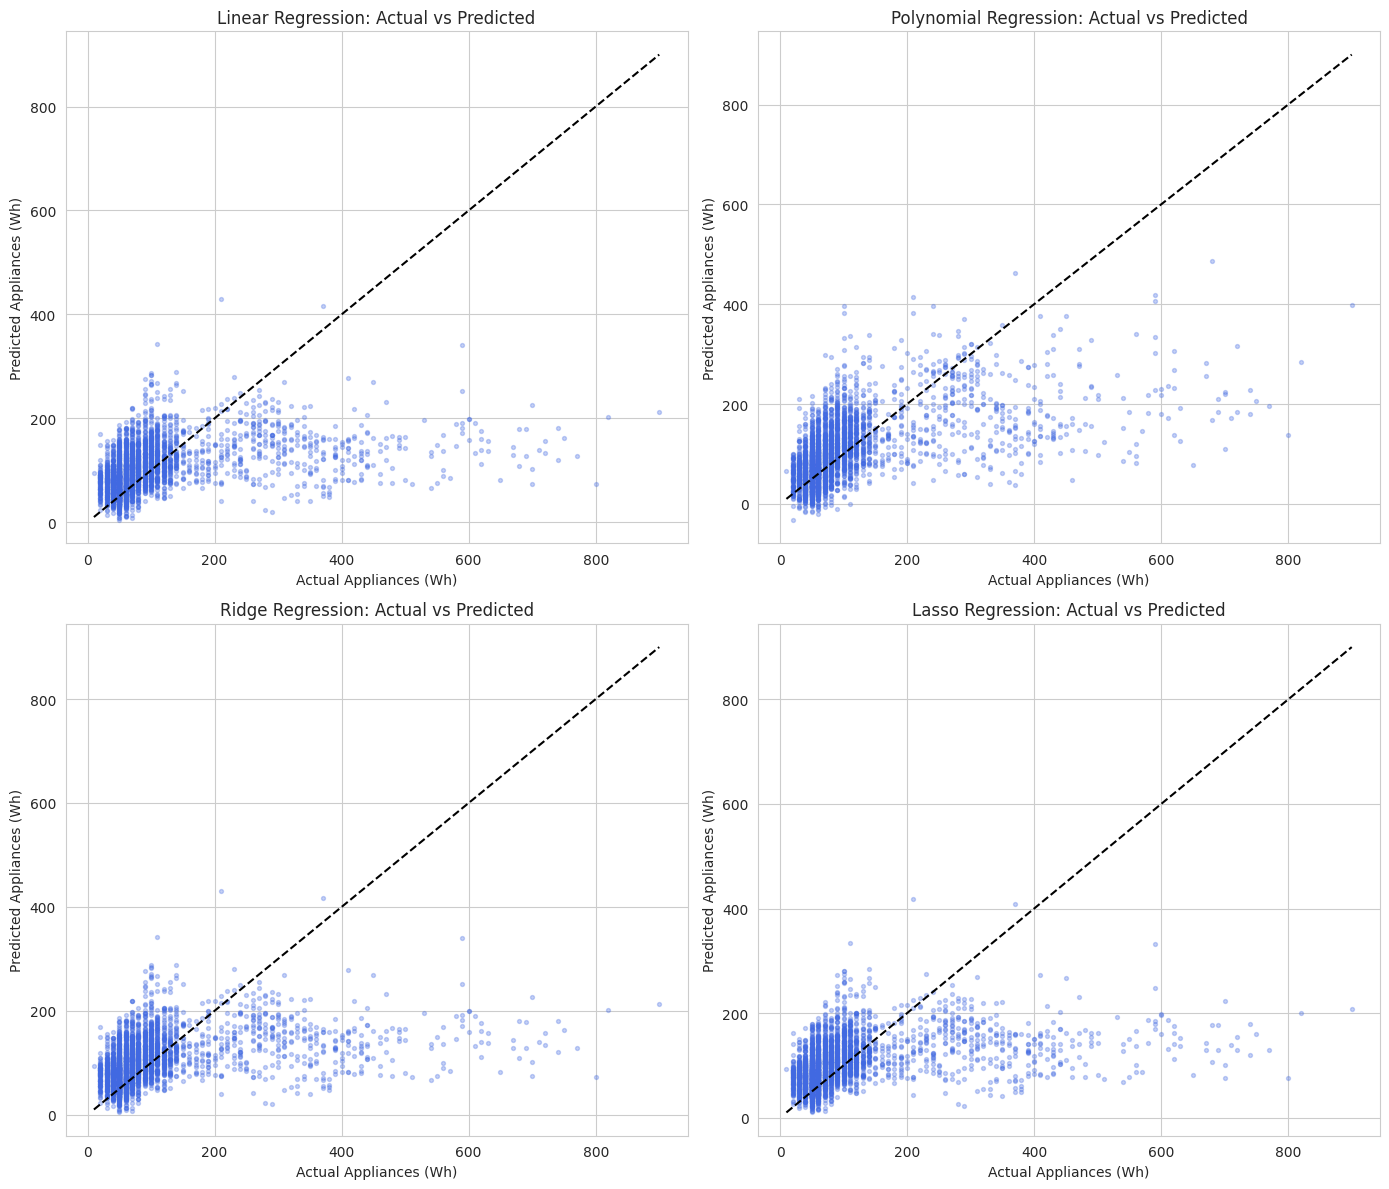

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, (model_name, y_pred) in zip(axes, regression_predictions.items()):
    ax.scatter(y_test_reg, y_pred, alpha=0.3, s=8, color="royalblue")
    ax.plot(
        [y_test_reg.min(), y_test_reg.max()],
        [y_test_reg.min(), y_test_reg.max()],
        color="black",
        linestyle="--"
    )
    ax.set_title(f"{model_name}: Actual vs Predicted")
    ax.set_xlabel("Actual Appliances (Wh)")
    ax.set_ylabel("Predicted Appliances (Wh)")

plt.tight_layout()
plt.show()

**Ridge and Lasso Feature Analysis**

In [ ]:
ridge_coefs = ridge_pipeline.named_steps["ridge"].coef_
lasso_coefs = lasso_pipeline.named_steps["lasso"].coef_

coef_comparison = pd.DataFrame({
    "Feature": X_reg.columns,
    "Ridge_Coefficient": ridge_coefs,
    "Lasso_Coefficient": lasso_coefs
})

coef_comparison["Abs_Lasso_Coefficient"] = coef_comparison["Lasso_Coefficient"].abs()
coef_comparison = coef_comparison.sort_values("Abs_Lasso_Coefficient", ascending=False).reset_index(drop=True)
coef_comparison

,Feature,Ridge_Coefficient,Lasso_Coefficient,Abs_Lasso_Coefficient
0,RH_1,60.409722,58.034779,58.034779
1,T3,56.257151,54.246231,54.246231
2,RH_2,-53.990560,-49.624825,49.624825
3,T6,44.394156,36.396166,36.396166
4,T2,-39.994884,-35.116000,35.116000
5,T_out,-43.039099,-23.967729,23.967729
6,RH_8,-18.786473,-19.030507,19.030507
7,month,-17.931383,-18.076963,18.076963
8,lights,14.763455,14.866853,14.866853
9,T9,-17.744545,-14.079181,14.079181


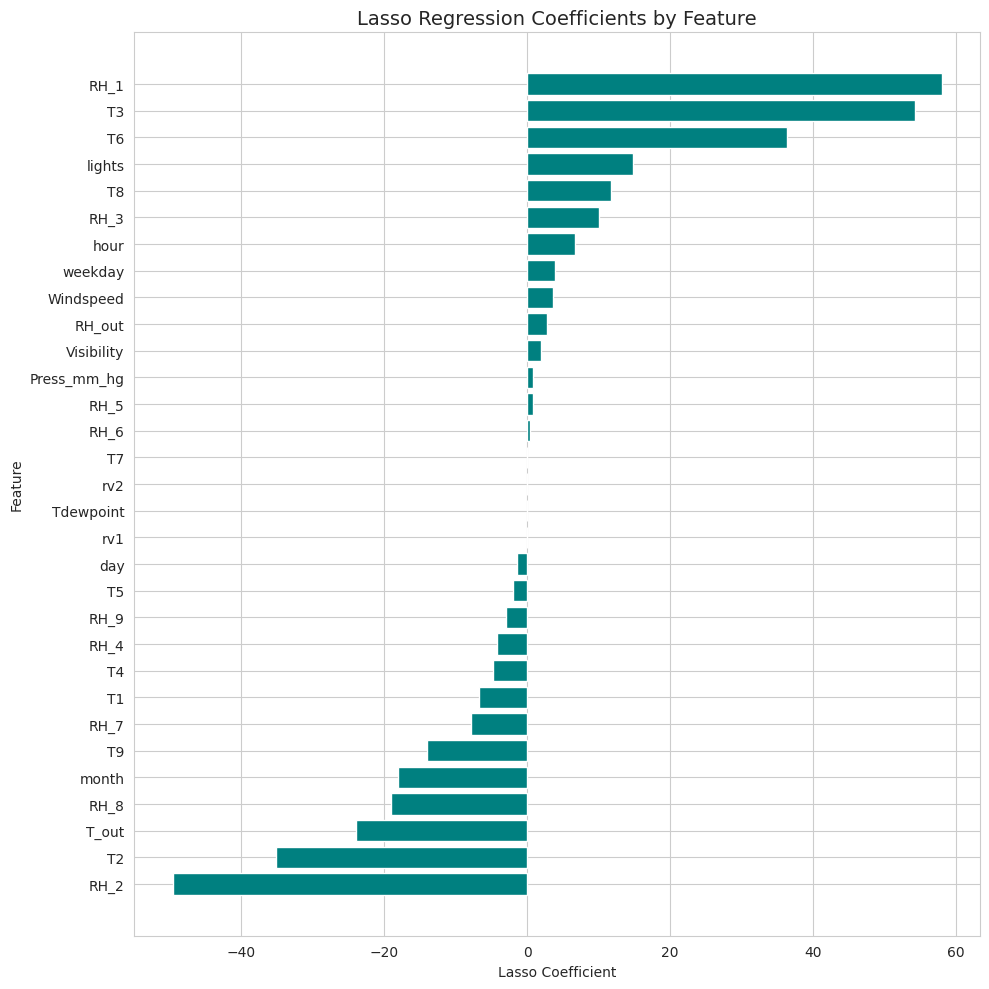

In [ ]:
plt.figure(figsize=(10, 10))
sorted_by_lasso = coef_comparison.sort_values("Lasso_Coefficient")
plt.barh(sorted_by_lasso["Feature"], sorted_by_lasso["Lasso_Coefficient"], color="teal")
plt.title("Lasso Regression Coefficients by Feature", fontsize=14)
plt.xlabel("Lasso Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
zero_or_near_zero = coef_comparison[coef_comparison["Abs_Lasso_Coefficient"] < 1e-3]
print("Features with Lasso coefficients closest to zero (effectively removed):")
print(zero_or_near_zero[["Feature", "Lasso_Coefficient"]])

Features with Lasso coefficients closest to zero (effectively removed):
      Feature  Lasso_Coefficient
27         T7                0.0
28        rv2                0.0
29  Tdewpoint                0.0
30        rv1                0.0


**Classification Problem Setup**

`High_Consumption` is created using the median value of `Appliances` as a threshold:
- `0` → Normal Consumption (`Appliances` below the median)
- `1` → High Consumption (`Appliances` at or above the median)

In [ ]:
appliances_median = df["Appliances"].median()
df["High_Consumption"] = (df["Appliances"] >= appliances_median).astype(int)

print("Median Appliances threshold:", appliances_median)
print()
print("Class counts:")
print(df["High_Consumption"].value_counts())

Median Appliances threshold: 60.0

Class counts:
High_Consumption
1    12273
0     7462
Name: count, dtype: int64


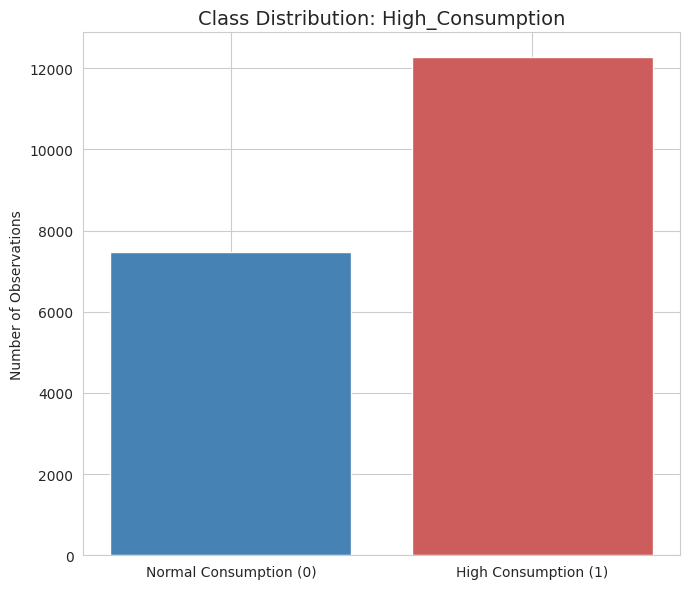

In [ ]:
plt.figure(figsize=(7, 6))
class_counts = df["High_Consumption"].value_counts().sort_index()
plt.bar(["Normal Consumption (0)", "High Consumption (1)"], class_counts.values, color=["steelblue", "indianred"])
plt.title("Class Distribution: High_Consumption", fontsize=14)
plt.ylabel("Number of Observations")
plt.tight_layout()
plt.show()

In [ ]:
X_clf = df.drop(columns=["Appliances", "High_Consumption"])
y_clf = df["High_Consumption"]

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

print("Training set shape:", X_train_clf.shape)
print("Test set shape:", X_test_clf.shape)

Training set shape: (15788, 31)
Test set shape: (3947, 31)


In [ ]:
def classification_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred)
    }

classification_results = {}

**Logistic Regression**

In [ ]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_clf_scaled, y_train_clf)
y_pred_log = log_reg.predict(X_test_clf_scaled)

classification_results["Logistic Regression"] = classification_metrics(y_test_clf, y_pred_log)

print(classification_report(y_test_clf, y_pred_log, target_names=["Normal", "High"]))

              precision    recall  f1-score   support

      Normal       0.66      0.63      0.65      1492
        High       0.78      0.81      0.79      2455

    accuracy                           0.74      3947
   macro avg       0.72      0.72      0.72      3947
weighted avg       0.74      0.74      0.74      3947



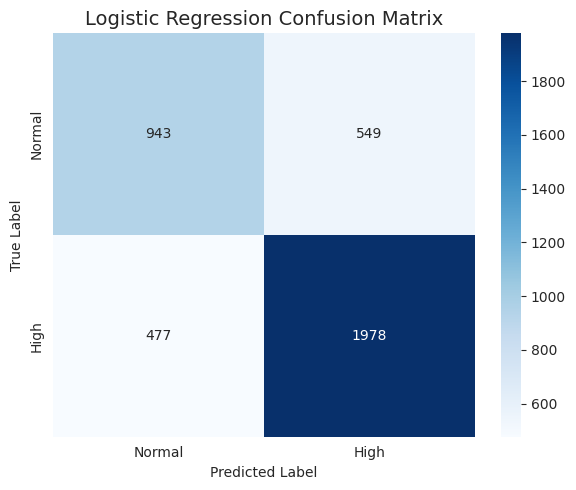

In [ ]:
cm_log = confusion_matrix(y_test_clf, y_pred_log)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal", "High"], yticklabels=["Normal", "High"])
plt.title("Logistic Regression Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

**KNN Classification**

In [ ]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_clf_scaled, y_train_clf)
y_pred_knn = knn.predict(X_test_clf_scaled)

classification_results["KNN (k=7)"] = classification_metrics(y_test_clf, y_pred_knn)

print(classification_report(y_test_clf, y_pred_knn, target_names=["Normal", "High"]))

              precision    recall  f1-score   support

      Normal       0.72      0.74      0.73      1492
        High       0.84      0.82      0.83      2455

    accuracy                           0.79      3947
   macro avg       0.78      0.78      0.78      3947
weighted avg       0.79      0.79      0.79      3947



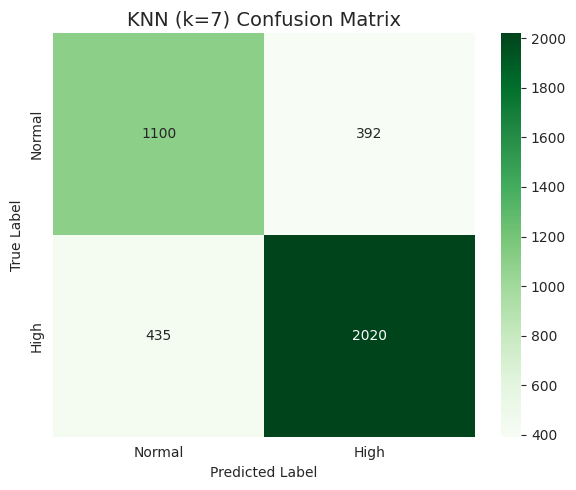

In [ ]:
cm_knn = confusion_matrix(y_test_clf, y_pred_knn)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Greens", xticklabels=["Normal", "High"], yticklabels=["Normal", "High"])
plt.title("KNN (k=7) Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

**KNN Hyperparameter Analysis**

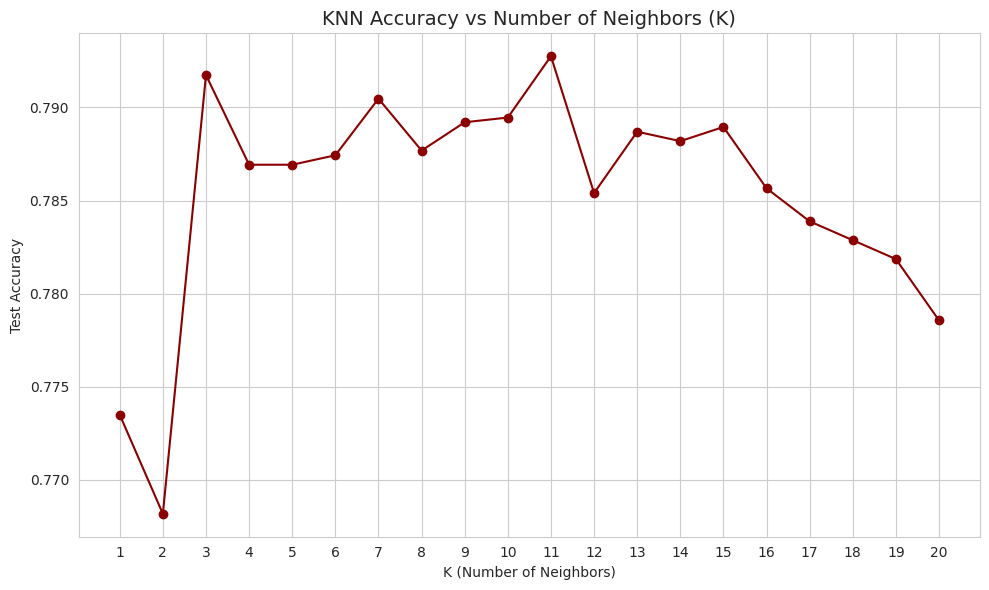

In [ ]:
k_values = range(1, 21)
k_accuracies = []

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train_clf_scaled, y_train_clf)
    y_pred_k = knn_k.predict(X_test_clf_scaled)
    k_accuracies.append(accuracy_score(y_test_clf, y_pred_k))

plt.figure(figsize=(10, 6))
plt.plot(list(k_values), k_accuracies, marker="o", color="darkred")
plt.title("KNN Accuracy vs Number of Neighbors (K)", fontsize=14)
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Test Accuracy")
plt.xticks(list(k_values))
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
best_k = list(k_values)[int(np.argmax(k_accuracies))]
best_k_accuracy = max(k_accuracies)
print("Best K value:", best_k)
print("Best K accuracy:", best_k_accuracy)

Best K value: 11
Best K accuracy: 0.7927539903724348


In [ ]:
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_clf_scaled, y_train_clf)
y_pred_knn_best = knn_best.predict(X_test_clf_scaled)

classification_results[f"KNN (best k={best_k})"] = classification_metrics(y_test_clf, y_pred_knn_best)

print(classification_report(y_test_clf, y_pred_knn_best, target_names=["Normal", "High"]))

              precision    recall  f1-score   support

      Normal       0.72      0.74      0.73      1492
        High       0.84      0.83      0.83      2455

    accuracy                           0.79      3947
   macro avg       0.78      0.78      0.78      3947
weighted avg       0.79      0.79      0.79      3947



**Classification Model Comparison**

In [ ]:
classification_comparison = pd.DataFrame(classification_results).T
classification_comparison = classification_comparison[["Accuracy", "Precision", "Recall", "F1 Score"]]
classification_comparison

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.740056,0.782746,0.805703,0.794059
KNN (k=7),0.790474,0.837479,0.822811,0.830080
KNN (best k=11),0.792754,0.837804,0.826884,0.832308


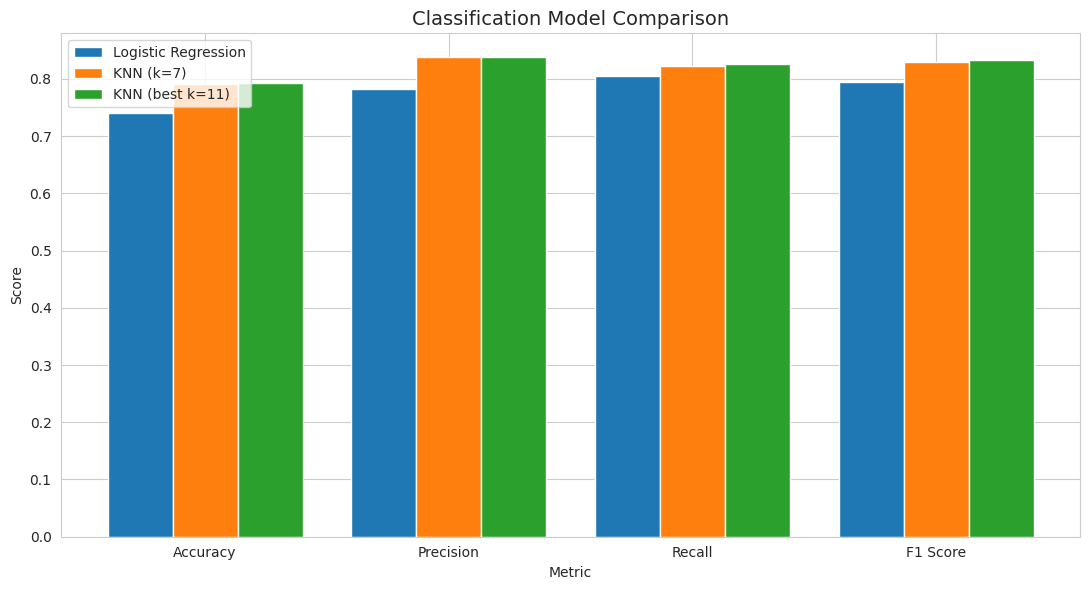

In [ ]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1 Score"]
x = np.arange(len(metrics_to_plot))
width = 0.8 / len(classification_comparison)

plt.figure(figsize=(11, 6))
for i, model_name in enumerate(classification_comparison.index):
    values = classification_comparison.loc[model_name, metrics_to_plot].values
    plt.bar(x + i * width, values, width=width, label=model_name)

plt.title("Classification Model Comparison", fontsize=14)
plt.xlabel("Metric")
plt.ylabel("Score")
plt.xticks(x + width * (len(classification_comparison) - 1) / 2, metrics_to_plot)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
best_classification_model = classification_comparison["F1 Score"].idxmax()
print("Best classification model based on F1 score:", best_classification_model)
print(classification_comparison.loc[best_classification_model])

Best classification model based on F1 score: KNN (best k=11)
Accuracy     0.792754
Precision    0.837804
Recall       0.826884
F1 Score     0.832308
Name: KNN (best k=11), dtype: float64


**Logistic Regression Feature Analysis**

In [ ]:
log_reg_coefs = log_reg.coef_[0]

logreg_coef_df = pd.DataFrame({
    "Feature": X_clf.columns,
    "Coefficient": log_reg_coefs
})
logreg_coef_df["Absolute Coefficient"] = logreg_coef_df["Coefficient"].abs()
logreg_coef_df = logreg_coef_df.sort_values("Absolute Coefficient", ascending=False).reset_index(drop=True)
logreg_coef_df

,Feature,Coefficient,Absolute Coefficient
0,RH_1,1.337522,1.337522
1,T8,1.117717,1.117717
2,RH_8,-0.853336,0.853336
3,RH_2,-0.848929,0.848929
4,T6,0.826315,0.826315
5,T3,0.806495,0.806495
6,lights,0.737507,0.737507
7,T7,-0.577184,0.577184
8,T2,-0.569489,0.569489
9,T9,-0.472074,0.472074


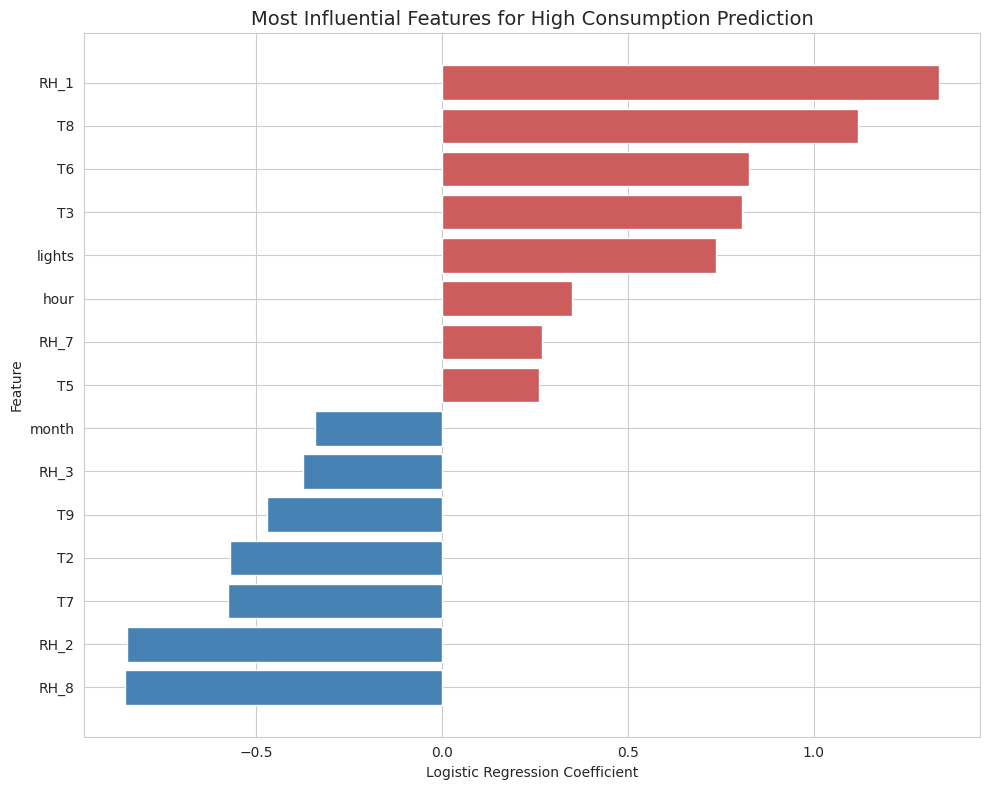

In [ ]:
top_features = logreg_coef_df.head(15).sort_values("Coefficient")

plt.figure(figsize=(10, 8))
colors = ["indianred" if c > 0 else "steelblue" for c in top_features["Coefficient"]]
plt.barh(top_features["Feature"], top_features["Coefficient"], color=colors)
plt.title("Most Influential Features for High Consumption Prediction", fontsize=14)
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
correlation_with_appliances = df.corr()["Appliances"].drop(["Appliances", "High_Consumption"]).sort_values(ascending=False)
top_positive_corr = correlation_with_appliances.head(5)
top_negative_corr = correlation_with_appliances.tail(5)

print("Top 5 positive correlations with Appliances:")
print(top_positive_corr)
print()
print("Top 5 negative correlations with Appliances:")
print(top_negative_corr)

Top 5 positive correlations with Appliances:
hour      0.216792
lights    0.197278
T2        0.120073
T6        0.117638
T_out     0.099155
Name: Appliances, dtype: float64

Top 5 negative correlations with Appliances:
RH_7     -0.055642
RH_2     -0.060465
RH_6     -0.083178
RH_8     -0.094039
RH_out   -0.152282
Name: Appliances, dtype: float64


In [ ]:
top_lasso_features = coef_comparison.sort_values("Abs_Lasso_Coefficient", ascending=False).head(5)["Feature"].tolist()
top_logreg_features = logreg_coef_df.head(5)["Feature"].tolist()

poly_vs_linear_r2_gain = regression_results["Polynomial Regression"]["R2"] - regression_results["Linear Regression"]["R2"]

print("Top 5 features by Lasso coefficient magnitude:", top_lasso_features)
print("Top 5 features by Logistic Regression coefficient magnitude:", top_logreg_features)
print("R2 gain of Polynomial Regression over Linear Regression:", round(poly_vs_linear_r2_gain, 4))
print("Best regression model:", best_regression_model)
print("Best classification model:", best_classification_model)
print("Best K value found for KNN:", best_k)
print("Peak average hourly consumption occurs at hour:", int(hourly_avg.idxmax()), "with", round(hourly_avg.max(), 2), "Wh")
print("Lowest average hourly consumption occurs at hour:", int(hourly_avg.idxmin()), "with", round(hourly_avg.min(), 2), "Wh")

Top 5 features by Lasso coefficient magnitude: ['RH_1', 'T3', 'RH_2', 'T6', 'T2']
Top 5 features by Logistic Regression coefficient magnitude: ['RH_1', 'T8', 'RH_8', 'RH_2', 'T6']
R2 gain of Polynomial Regression over Linear Regression: 0.1506
Best regression model: Polynomial Regression
Best classification model: KNN (best k=11)
Best K value found for KNN: 11
Peak average hourly consumption occurs at hour: 18 with 190.36 Wh
Lowest average hourly consumption occurs at hour: 3 with 48.24 Wh
